# Language Detection - TinyBERT_General_4L_312D

---

### Import Libraries

In [ ]:
!pip install -q transformers datasets accelerate evaluate torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.9 MB/s eta 0:00:00


In [ ]:
import os
import torch
import numpy as np
import evaluate
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

In [ ]:
from transformers import set_seed

set_seed(42)

### Setup Device

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


### Load Dataset


In [ ]:
print("Loading papluca/language-identification dataset...")
dataset = load_dataset("papluca/language-identification")

Loading papluca/language-identification dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/4.99k [00:00<?, ?B/s]

train.csv:   0%|          | 0.00/12.0M [00:00<?, ?B/s]

valid.csv:   0%|          | 0.00/1.71M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/1.69M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/70000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [ ]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['labels', 'text'],
        num_rows: 70000
    })
    validation: Dataset({
        features: ['labels', 'text'],
        num_rows: 10000
    })
    test: Dataset({
        features: ['labels', 'text'],
        num_rows: 10000
    })
})


In [ ]:
train_data = dataset["train"]
val_data = dataset["validation"]
test_data = dataset["test"]

### Labels Encoding

In [ ]:
unique_labels = sorted(list(set(train_data["labels"])))
num_labels = len(unique_labels)

print(f"Detected {num_labels} distinct languages: {unique_labels}")

Detected 20 distinct languages: ['ar', 'bg', 'de', 'el', 'en', 'es', 'fr', 'hi', 'it', 'ja', 'nl', 'pl', 'pt', 'ru', 'sw', 'th', 'tr', 'ur', 'vi', 'zh']


In [ ]:
id2label = {i: label for i, label in enumerate(unique_labels)}
label2id = {label: i for i, label in id2label.items()}

In [ ]:
def encode_labels(examples):
    examples["label"] = [label2id[lbl] for lbl in examples["labels"]]
    return examples

In [ ]:
train_data = train_data.map(encode_labels, batched=True)
val_data = val_data.map(encode_labels, batched=True)
test_data = test_data.map(encode_labels, batched=True)

Map:   0%|          | 0/70000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

### Load Tokenizer

In [ ]:
# model_name = "distilbert-base-multilingual-cased"
model_name = "huawei-noah/TinyBERT_General_4L_312D"
tokenizer = AutoTokenizer.from_pretrained(model_name)

config.json:   0%|          | 0.00/409 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

In [ ]:
def tokenize_function(examples):
    # Tokenize the text strings
    return tokenizer(examples["text"], truncation=True, max_length=64, padding=False)

print("Tokenizing")
columns_to_remove = ['labels', 'text']

tokenized_train = train_data.map(tokenize_function, batched=True, remove_columns=columns_to_remove)
tokenized_val = val_data.map(tokenize_function, batched=True, remove_columns=columns_to_remove)
tokenized_test = test_data.map(tokenize_function, batched=True, remove_columns=columns_to_remove)


Tokenizing


Map:   0%|          | 0/70000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [ ]:
tokenized_train

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 70000
})

### Load Pre-trained Model

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
).to(device)

pytorch_model.bin:   0%|          | 0.00/62.7M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/71 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: huawei-noah/TinyBERT_General_4L_312D
Key                                        | Status     | 
-------------------------------------------+------------+-
fit_denses.{0, 1, 2, 3, 4}.bias            | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
fit_denses.{0, 1, 2, 3, 4}.weight          | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not o

### Setup Evaluation Metric

In [ ]:
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_metric.compute(
        predictions=predictions,
        references=labels,
    )

    f1 = f1_metric.compute(
        predictions=predictions,
        references=labels,
        average="macro",
    )

    return {
        "accuracy": accuracy["accuracy"],
        "f1_macro": f1["f1"],
    }

# Dynamic padding data collator for faster batch processing
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model.safetensors:   0%|          | 0.00/62.7M [00:00<?, ?B/s]

### Training Arguments

In [ ]:
learning_rate = 3e-5
batch_size = 32
epochs = 5


training_args = TrainingArguments(
    output_dir="./language_detector_model_TinyBERT_General_4L_312D",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=learning_rate,

    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,

    num_train_epochs=epochs,

    weight_decay=0.01,
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    fp16=torch.cuda.is_available(),
    report_to="none"
)


### Initialize Trainer

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,

    data_collator=data_collator,

    compute_metrics=compute_metrics,
)

### Fine-Tuning

In [ ]:
print("Starting training loop...")
trainer.train()

Starting training loop...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.178150,0.198977,0.967100,0.966974
2,0.095064,0.188230,0.952900,0.951027
3,0.059064,0.234415,0.953900,0.952658
4,0.071630,0.143690,0.974000,0.973906
5,0.045824,0.243088,0.952300,0.951089
6,0.056686,0.192379,0.968300,0.968025
7,0.038301,0.161347,0.972200,0.972038
8,0.043644,0.184131,0.971500,0.971167
9,0.030270,0.207842,0.967900,0.967534
10,0.021375,0.216311,0.967300,0.966901


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias'].
There were unexpected keys in the checkp

TrainOutput(global_step=21880, training_loss=0.13209916524303025, metrics={'train_runtime': 699.4742, 'train_samples_per_second': 1000.752, 'train_steps_per_second': 31.281, 'total_flos': 1256137557598848.0, 'train_loss': 0.13209916524303025, 'epoch': 10.0})

### Evaluation

In [ ]:
# Validation Evaluation
val_results = trainer.evaluate(tokenized_val)
print("Validation Results:", val_results)

Validation Results: {'eval_loss': 0.14403390884399414, 'eval_accuracy': 0.9741, 'eval_f1_macro': 0.9740009883476924, 'eval_runtime': 3.884, 'eval_samples_per_second': 2574.635, 'eval_steps_per_second': 80.586, 'epoch': 10.0}


In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

val_predictions_output = trainer.predict(tokenized_val)

y_true = val_predictions_output.label_ids
y_pred = np.argmax(
    val_predictions_output.predictions,
    axis=1
)


# Classification Report
report = classification_report(
    y_true,
    y_pred,
    target_names=unique_labels
)

print(report)

              precision    recall  f1-score   support

          ar       1.00      0.99      1.00       500
          bg       0.97      0.91      0.94       500
          de       0.99      0.99      0.99       500
          el       0.94      0.98      0.96       500
          en       0.98      0.99      0.99       500
          es       0.98      0.98      0.98       500
          fr       0.99      0.99      0.99       500
          hi       1.00      0.95      0.98       500
          it       0.99      1.00      0.99       500
          ja       0.99      1.00      1.00       500
          nl       0.99      0.99      0.99       500
          pl       0.98      0.98      0.98       500
          pt       0.98      0.99      0.99       500
          ru       0.91      0.97      0.94       500
          sw       0.92      0.99      0.95       500
          th       0.93      0.86      0.89       500
          tr       0.99      0.98      0.98       500
          ur       1.00    

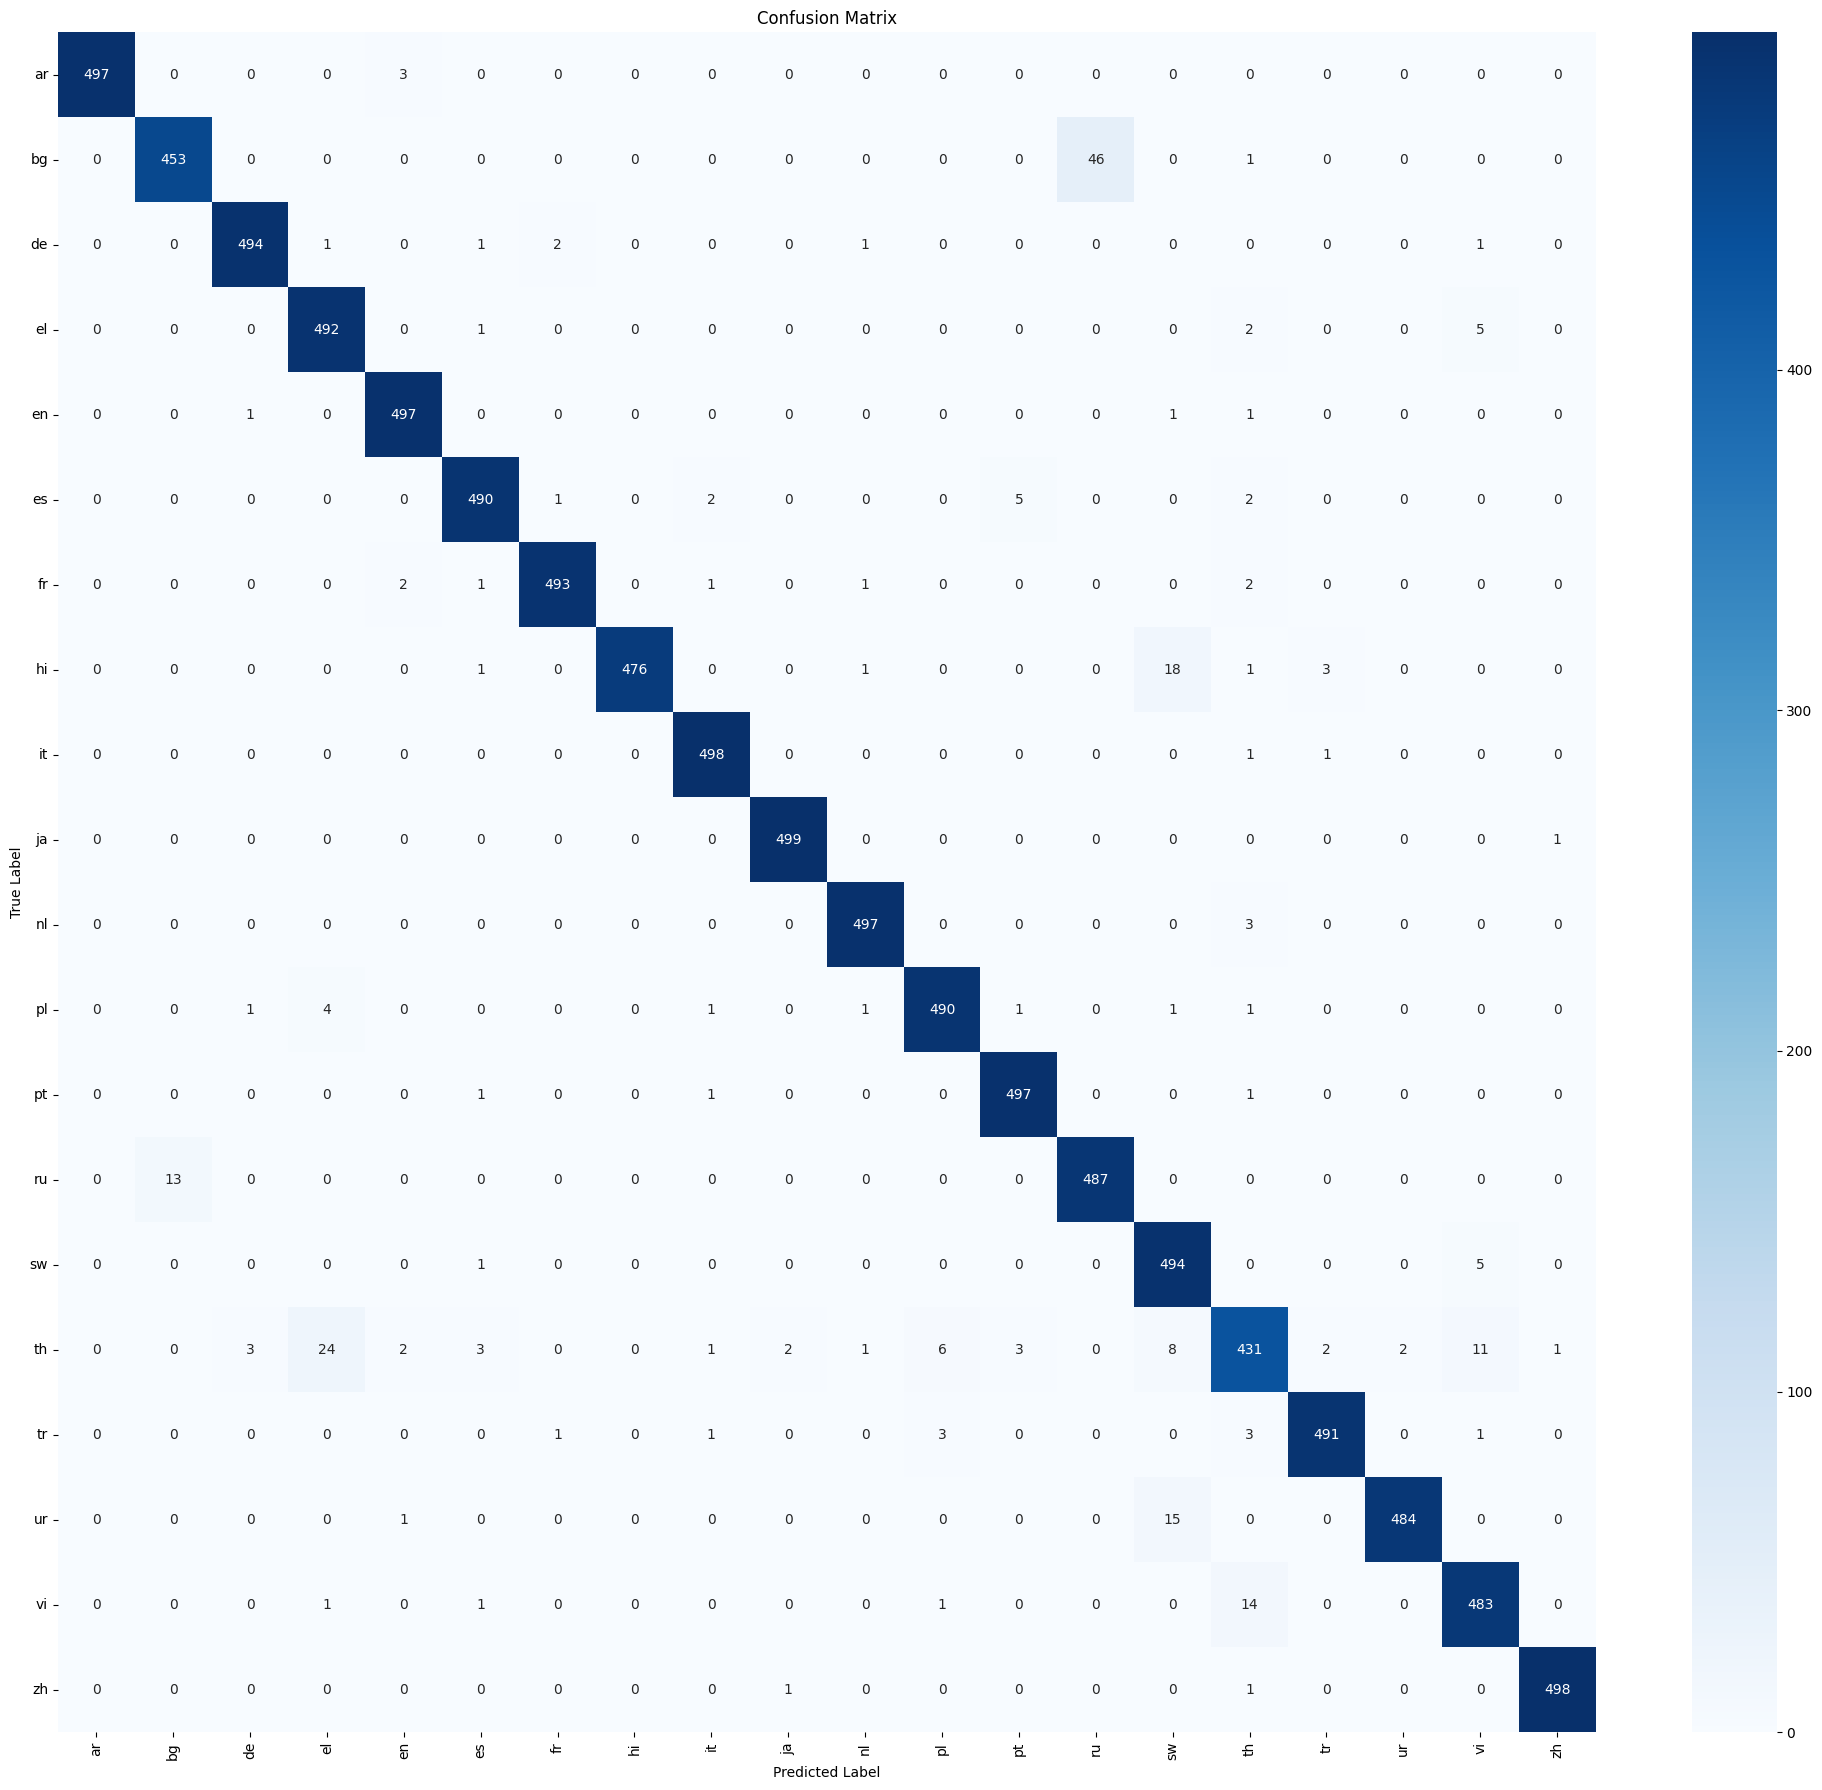

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(20, 18))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=unique_labels,
    yticklabels=unique_labels
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Test Evaluation
test_results = trainer.evaluate(tokenized_test)
print("Test Results:", test_results)

Test Results: {'eval_loss': 0.17992495000362396, 'eval_accuracy': 0.9662, 'eval_f1_macro': 0.966070631276545, 'eval_runtime': 4.0976, 'eval_samples_per_second': 2440.438, 'eval_steps_per_second': 76.386, 'epoch': 10.0}


### Save Model

In [ ]:
standard_model_path = "./language_detector_transformer_TinyBERT_General_4L_312D"

In [ ]:
model.save_pretrained(standard_model_path)
tokenizer.save_pretrained(standard_model_path)
print(f"Model files safely written to '{standard_model_path}'")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model files safely written to './language_detector_transformer_TinyBERT_General_4L_312D'


### Inference

In [ ]:
from transformers import pipeline

classifier = pipeline(
    task="text-classification",
    model=standard_model_path,
    tokenizer=standard_model_path,
    device=-1,
)

Loading weights:   0%|          | 0/73 [00:00<?, ?it/s]

In [ ]:
texts = [
    "Hello, how are you today?",
    "كيف حالك اليوم",
    "Bonjour tout le monde",
    "Guten Morgen",
]

predictions = classifier(texts)

for text, prediction in zip(texts, predictions):
    print(f"Text: {text}")
    print(f"Prediction: {prediction}\n")

Text: Hello, how are you today?
Prediction: {'label': 'en', 'score': 0.45616620779037476}

Text: كيف حالك اليوم
Prediction: {'label': 'ar', 'score': 0.9995148181915283}

Text: Bonjour tout le monde
Prediction: {'label': 'fr', 'score': 0.9987077713012695}

Text: Guten Morgen
Prediction: {'label': 'th', 'score': 0.8236539959907532}



----

### Model Zipping

In [ ]:
zip_name = standard_model_path.replace("./", "") + ".zip"

In [ ]:
!zip -r {zip_name} {standard_model_path}

  adding: language_detector_transformer_TinyBERT_General_4L_312D/ (stored 0%)
  adding: language_detector_transformer_TinyBERT_General_4L_312D/tokenizer_config.json (deflated 42%)
  adding: language_detector_transformer_TinyBERT_General_4L_312D/tokenizer.json (deflated 71%)
  adding: language_detector_transformer_TinyBERT_General_4L_312D/config.json (deflated 58%)
  adding: language_detector_transformer_TinyBERT_General_4L_312D/model.safetensors (deflated 7%)
